In [1]:
import os 
import torch
import torch.nn.functional as F
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from torchvision import models
from tqdm import tqdm
from PIL import Image
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torchvision.utils import make_grid
from torchvision import transforms as T, datasets

#### Root Directory for my dataset

In [63]:
dataset_dir = r'/home/Kellspell/PY-AI/Full-Stack/notebooks/dataset'

#### Total number of classes

In [64]:
class_name = os.listdir(dataset_dir)
len(class_name)

2

#### Checking for cuda availability


In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:{}".format(device))

device:cpu


#### Dataset Preparation


In [66]:
data_transform = T.Compose([
    T.Resize(size=(224, 224)), # resizing all images down to 224 by 224 formate
    T.RandomRotation(degrees=(-20, +20)), # Randomly, rotate images by +/- 20 degrees
    T.ToTensor(), # Converting images into tensors
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]), # Normalize by 3 means 3 std of image net , 3 channels
])

In [67]:
data = datasets.ImageFolder(dataset_dir, transform=data_transform)
total_count = len(data)

In [68]:
# Display the number of images thats has been augmented
total_count

842

In [69]:
data.classes

['Forged', 'Original']

#### Spliting the data


In [70]:
train_count = int(0.6 * total_count)
valid_count = int(0.3 * total_count)
test_count = total_count - train_count - valid_count
train_data, val_data, test_data = torch.utils.data.random_split(data, (train_count, valid_count, test_count))

In [71]:
train_data.dataset

Dataset ImageFolder
    Number of datapoints: 842
    Root location: /home/Kellspell/PY-AI/Full-Stack/notebooks/dataset
    StandardTransform
Transform: Compose(
               Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
               RandomRotation(degrees=[-20.0, 20.0], interpolation=nearest, expand=False, fill=0)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [72]:
len(train_data.indices)

505

In [73]:
len(test_data.indices)

85

In [74]:
len(val_data.indices)

252

#### Defining some functions


In [75]:
def show_image(image, label, get_denormalize = True):
    image = image.permute(1,2,0)
    mean = torch.FloatTensor([0.485, 0.456, 0.406])
    std = torch.FloatTensor([0.229, 0.224, 0.225])
    
    if get_denormalize == True:
        image = image * std + mean
        image = np.clip(image,0,1)
        plt.imshow(image)
        plt.title(label)
        
    else:
        plt.imshow(image)
        plt.title(label)

# def show_grid(image, title = None):
#     image = image.permute(1,2,0)
#     mean = torch.FloatTensor([0.485, 0.456, 0.406])
#     std = torch.FloatTensor([0.229, 0.224, 0.225])
    
#     image = image * std + mean
#     image = np.clip(image,0,1)
    
#     plt.figure(figsize=[15, 15])
#     plt.imshow(image)
        
#     if title != None:
#         plt.title(title)
        
def accuracy(y_pred, y_true):
    y_pred = F.softmax(y_pred, dim=1)
    top_p, top_class = y_pred.topk(1, dim=1)
    equals = top_class = y_true.view(*top_class.shape)
    return torch.mean(equals.type(torch.FloatTensor))        
                

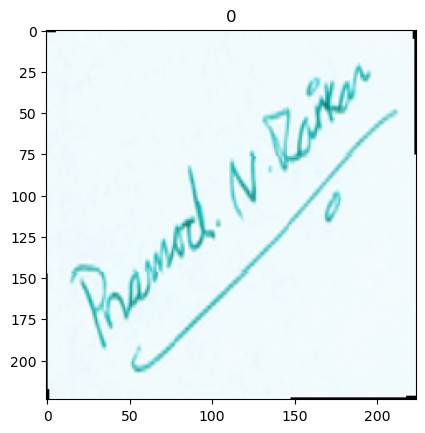

In [76]:
img, label = train_data[0]
show_image(img, label)

#### Data Loader

In [77]:
trainloader = DataLoader(train_data, batch_size=32, shuffle=True)
print("No. of batches in trainloader: {}".format(len(trainloader)))
print("No. of total examples: {}".format(len(trainloader.dataset)))

validationloader = DataLoader(val_data, batch_size=32, shuffle=True)
print("No. of batches in validationloader: {}".format(len(validationloader)))
print("No. of total examples: {}".format(len(trainloader.dataset)))

testloader = DataLoader(test_data, batch_size=32, shuffle=False)
print("No. of batches in testloader: {}".format(len(testloader)))
print("No. of total examples: {}".format(len(trainloader.dataset)))

No. of batches in trainloader: 16
No. of total examples: 505
No. of batches in validationloader: 8
No. of total examples: 505
No. of batches in testloader: 3
No. of total examples: 505


#### Let's create our model

In [47]:
model = models.resnet34(pretrained=True)
model.fc = nn.Sequential(
    nn.Dropout(0.1),
    nn.Linear(model.fc.in_features, len(class_name))
)
model = model.to(device)

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=1e-3, momentum=0.9)

##### Let's Create a function to train our model

In [52]:
def train_model(model, criterion, optimizer, trainloader, testloader):
    total_train_loss = 0
    total_test_loss = 0
    
    model.train()
    with tqdm(trainloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'training...')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output = model(images)
            
            loss = criterion(output, idxs)
            total_train_loss += loss.item()
            
            loss.backward()
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)
    model.eval()
    with tqdm(testloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing...')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output = model(images)
            
            loss = criterion(output, idxs)
            total_test_loss += loss.item()
    train_acc = total_train_loss / len(train_data)
    test_acc = total_test_loss / len(val_data)
    print(f"Train Loss: {train_acc:.4f}  Test Loss: {test_acc:.4f}")        


In [53]:
%%time
epochs=5
for i in range(epochs):
    print(f"Epoch: {i + 1}/{epochs}")
    train_model(model, criterion, optimizer, trainloader, validationloader)

Epoch: 1/5


Train Loss: 0.0231  Test Loss: 0.0205
Epoch: 2/5


Train Loss: 0.0189  Test Loss: 0.0201
Epoch: 3/5


Train Loss: 0.0160  Test Loss: 0.0159
Epoch: 4/5


Train Loss: 0.0132  Test Loss: 0.0153
Epoch: 5/5


Train Loss: 0.0103  Test Loss: 0.0099
CPU times: user 50min 57s, sys: 12.1 s, total: 51min 9s
Wall time: 26min 36s


##### Save the model

In [59]:
path = r'/home/Kellspell/PY-AI/Full-Stack/saved-model/model.pt'
torch.save(model, path)

#### Loading the saved model

In [61]:
model = torch.load(path, weights_only=False)
model.eval()


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Model evaluation

In [78]:
def evaluation(model, criterion, optimizer, testloader):
    total_test_loss = 0
    model.eval()
    with tqdm(testloader, unit='batch', leave=False) as pbar:
        pbar.set_description(f'testing...')
        for images, idxs in pbar:
            images = images.to(device, non_blocking=True)
            idxs = idxs.to(device, non_blocking=True)
            output = model(images)
            
            loss = criterion(output, idxs)
            total_test_loss += loss.item()
            
    test_acc = total_test_loss / len(val_data)
    print(f"Test Loss: {test_acc:.4f}")

In [79]:
# Let's call the eval
evaluation(model, criterion, optimizer, testloader)

Test Loss: 0.0032


#### Predictions
Let's test our predictions

In [88]:
# Load the image and proccess it 
image = Image.open(r'/home/Kellspell/PY-AI/Full-Stack/notebooks/dataset/Original/00101001.png')
preprocess = transforms.Compose([
    transforms.Resize(size=(224, 224)),
    transforms.Grayscale(3),
    transforms.ToTensor()
])

image = preprocess(image)
image = image[:3]

# Convert the image into pytorch tensor and send it to device
image = image.unsqueeze(0).to(device)

# Making predictions
with torch.no_grad():
    logits = model(image)
    probs = torch.softmax(logits, dim=1)
    pred_label = torch.argmax(probs, dim=1)
    
# Print the prediction
print(f"Predicted Label: {pred_label.item()}")

# Map the predicted label to the corresponding class name 
predicted_class_name = data.classes[pred_label.item()]

# Print the prediction class names
print(f"Predicted Label Names: {predicted_class_name}")

    


Predicted Label: 1
Predicted Label Names: Original
